In [1]:
import os
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve
import matplotlib.pyplot as plt

from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.datasets.dataloaders import get_dataloaders_range_classify_RI
from whale_gunshot_localization.utils.transformations import get_image_transform_range_classify
from whale_gunshot_localization import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")

Using the GPU!


### Helper Functions

In [2]:
def evaluate_model(model, dataloader):
    
    # put model in evaluation mode
    model.eval()
    
    # get scale
    max_r = config['scaling']['max_r']
    
    # instantiate lists
    outputs_all, r_t, r_p, c_t, c_p = [], [], [], [], []
    
    for inputs, target_c, target_r in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        
        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            outputs_all += outputs.detach().tolist()
            r_t += (target_r.detach() * max_r).squeeze().tolist()
            c_t += target_c.detach().squeeze().tolist()
            r_p += (outputs[:,0].detach() * max_r).tolist()
            c_p += (F.softmax(outputs[:,1:].detach(), dim=1)[:,1] >= 0.5).tolist()
            
    return np.asarray(r_p).T, np.asarray(r_t).T, np.asarray(c_p).T, np.asarray(c_t).T, np.asarray(outputs_all)

def plot_range_regression(r_t, r_p, c_t, c_p):
    
    # get TPs
    TP_idx = np.where((c_p == 1) & (c_t == 1))[0]
    r_t_TP = r_t[TP_idx]
    r_p_TP = r_p[TP_idx]

    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 5000) # (r_t_TP.min(), r_t_TP.max())
    
    plt.plot(r_t_TP / 1000, r_p_TP / 1000, 'bo', markersize=1)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    
    return r_t_TP, r_p_TP

### Prepare for Evaluation

In [3]:
# get test set dataloader
dl = get_dataloaders_range_classify_RI(splits=['test'],
                                       batch_size=128,
                                       transform=get_image_transform_range_classify(),
                                       pin_memory=True,
                                       num_workers=20)

# load model
model = TCNRangeAndClassify(input_size=dl['test'].dataset.size[0], 
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.1).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

### Evaluate Model on Synthetic Data

Perform Evaluation

In [4]:
r_p, r_t, c_p, c_t, outputs_all = evaluate_model(model, dl['test'])

  0%|          | 0/717 [00:00<?, ?it/s]

Detection Statistics

In [5]:

acc = accuracy_score(c_t, c_p)
prec = precision_score(c_t, c_p)
recall = recall_score(c_t, c_p)

print("statistics")
print("-------------------")
print(f'Accuracy: {np.around(acc, 3)}')
print(f'Precision: {np.around(prec, 3)}')
print(f'Recall: {np.around(recall, 3)}')

statistics
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


Ranging Statistics

statistics
-------------------
RMSE: 348.174 m
MAE: 269.805 m
MAPE: 2.989 %


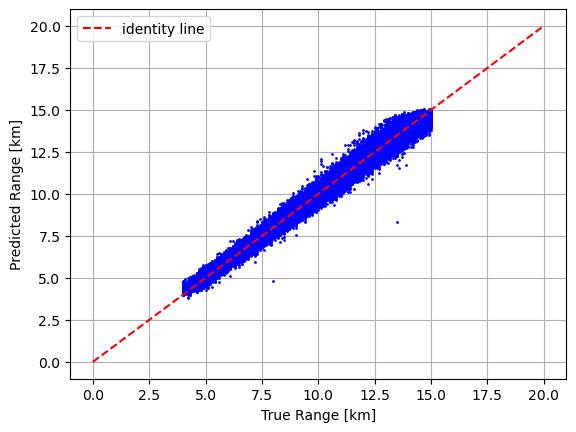

In [8]:
r_t_TP, r_p_TP = plot_range_regression(r_t, r_p, c_t, c_p)

rmse = np.sqrt(((r_t_TP - r_p_TP) ** 2).mean())
mae = np.abs(r_t_TP - r_p_TP).mean()
mape = np.abs((r_t_TP - r_p_TP) / r_t_TP).mean()

print("statistics")
print("-------------------")
print(f'RMSE: {np.around(rmse, 3)} m')
print(f'MAE: {np.around(mae, 3)} m')
print(f'MAPE: {np.around(mape * 100, 3)} %')